In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("../Data/Retailsalesdata.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [34]:
df.shape

(1000, 9)

In [35]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [36]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [39]:
df['Date'] = pd.to_datetime(df['Date'])

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [41]:
df['sales'] = df['Price per Unit'] * df['Quantity']

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   sales             1000 non-null   int64         
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 78.3 KB


In [43]:
df.groupby('Product Category')['sales'].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: sales, dtype: int64

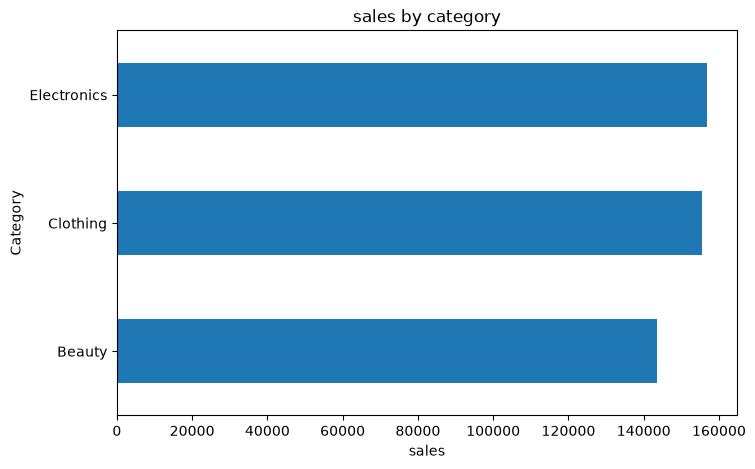

In [44]:
df.groupby('Product Category')['sales'].sum().sort_values().plot(kind='barh' , figsize=(8,5))
plt.title('sales by category')
plt.xlabel('sales')
plt.ylabel('Category')
plt.show()

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   sales             1000 non-null   int64         
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 78.3 KB


In [46]:
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False).head(10)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

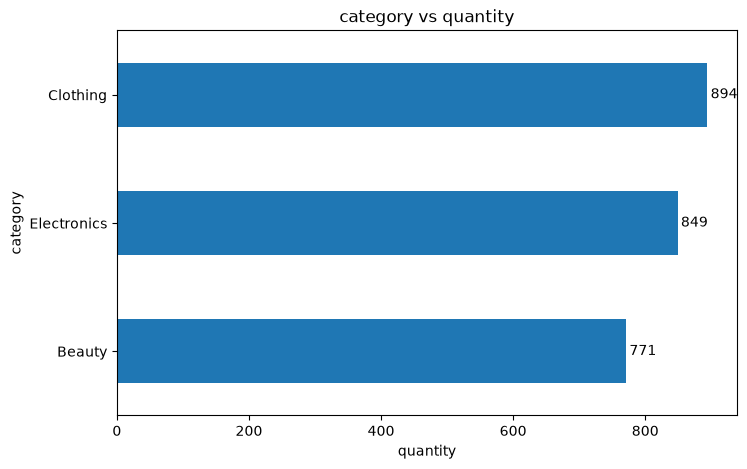

In [ ]:
data = df.groupby('Product Category')['Quantity'].sum().sort_values()
ax = data.plot(kind='barh', figsize=(8,5))
for i,v in enumerate(data):
    ax.text(v + 5, i, str(v), va='center')
plt.title('category vs quantity')
plt.xlabel('quantity')
plt.ylabel('category')
plt.show()

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   sales             1000 non-null   int64         
dtypes: datetime64[us](1), int64(6), str(3)
memory usage: 78.3 KB


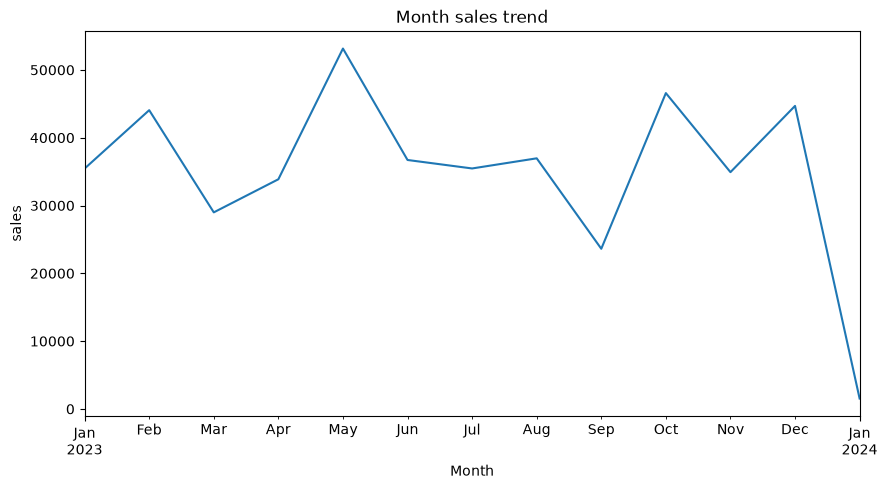

In [52]:
df['Month'] = df['Date'].dt.to_period('M')
monthlysales  = df.groupby('Month')['sales'].sum()
monthlysales.plot(figsize=(10,5))
plt.title('Month sales trend')
plt.xlabel('Month')
plt.ylabel('sales')
plt.show()

In [ ]:
df.groupby('Gender')['sales'].sum().sort_values(ascending=False)
plt.AbstractContextManager

Gender
Female    232840
Male      223160
Name: sales, dtype: int64

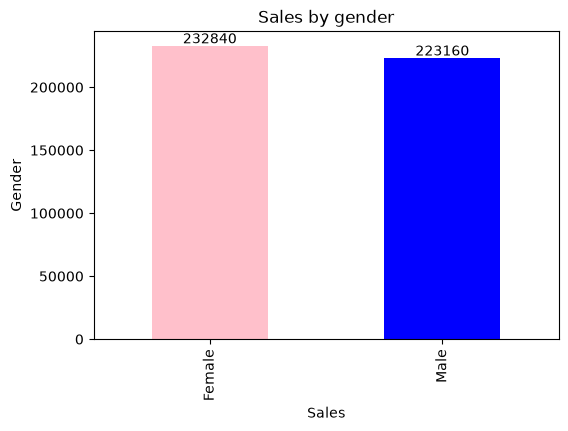

In [58]:
data2 = df.groupby('Gender')['sales'].sum()
az = data2.plot(kind='bar',figsize=(6,4), color=['Pink','Blue'])
for i,v in enumerate(data2):
    az.text(i, v + 2000, str(v), ha='center')
plt.title('Sales by gender')
plt.xlabel('Sales')
plt.ylabel('Gender')
plt.show()

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   sales             1000 non-null   int64         
 10  Month             1000 non-null   period[M]     
dtypes: datetime64[us](1), int64(6), period[M](1), str(3)
memory usage: 86.1 KB


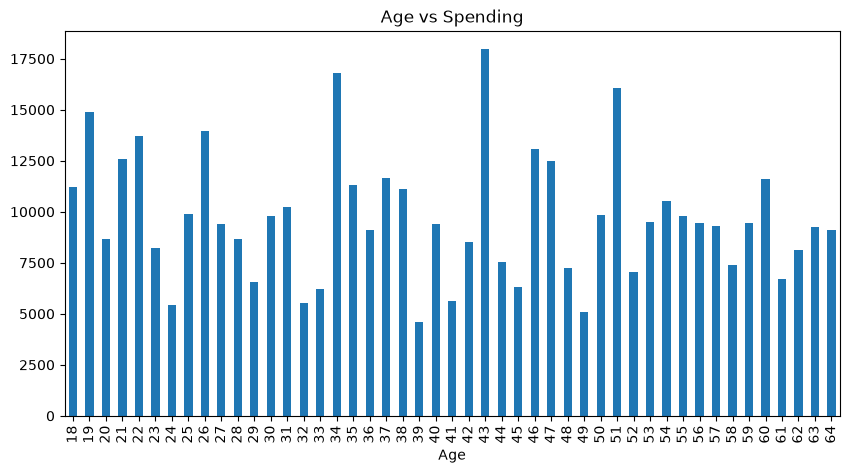

In [ ]:
df.groupby('Age')['sales'].sum().plot(kind = 'bar',figsize=(10,5))
plt.title('Age vs Spending')
save_plot('Age vs Spending')
plt.show()

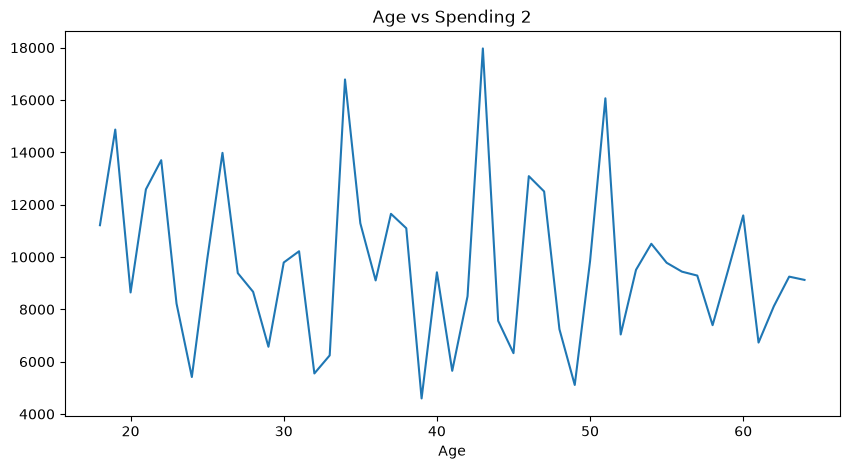

In [66]:
df.groupby('Age')['sales'].sum().plot(figsize=(10,5))
plt.title('Age vs Spending 2')
plt.show()

In [64]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

TO SAVE THE GRAPHS OR CHARTS MADE


In [67]:
save_plot('Age vs Spending')
save_plot('Age vs Spending 2')
save_plot('Sales by gender')
save_plot('Month sales trend')
save_plot('category vs quantity')
save_plot('sales by category')

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   sales             1000 non-null   int64         
 10  Month             1000 non-null   period[M]     
dtypes: datetime64[us](1), int64(6), period[M](1), str(3)
memory usage: 86.1 KB


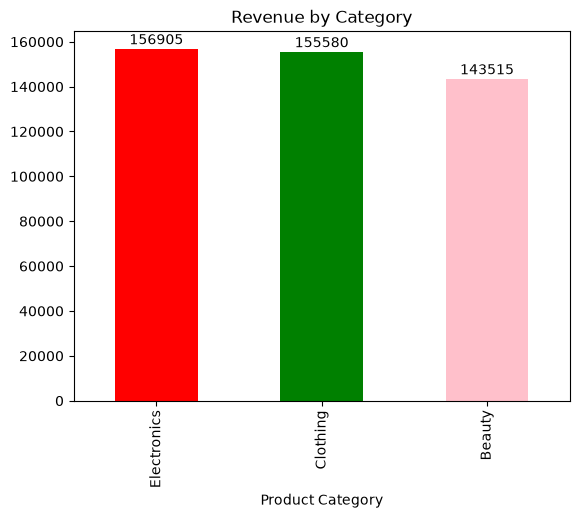

In [73]:
data3 = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
av = data3.plot(kind='bar', color = ['Red','green','pink'])
for i,v in enumerate(data3):
    av.text(i, v + 2000, str(v), ha='center')
plt.title('Revenue by Category')
plt.show()

In [74]:
save_plot('Revenue by Category')

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   sales             1000 non-null   int64         
 10  Month             1000 non-null   period[M]     
dtypes: datetime64[us](1), int64(6), period[M](1), str(3)
memory usage: 86.1 KB


In [76]:
avg_spend = df.groupby('Customer ID')['Total Amount'].sum().mean()
print("Avg spending per customer: ", avg_spend)

Avg spending per customer:  456.0


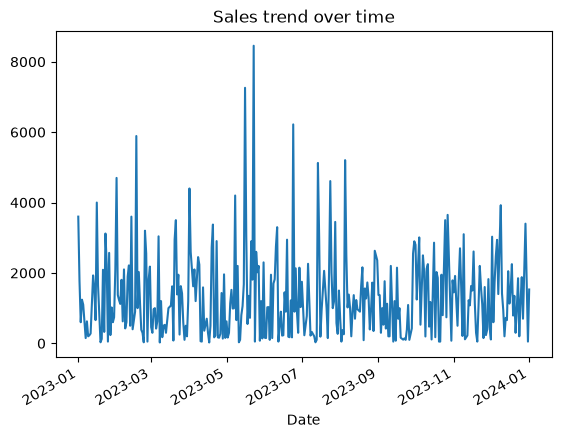

In [77]:
df['Date'] = pd.to_datetime(df['Date'])
df.groupby('Date')['Total Amount'].sum().plot()
plt.title('Sales trend over time')
plt.show()

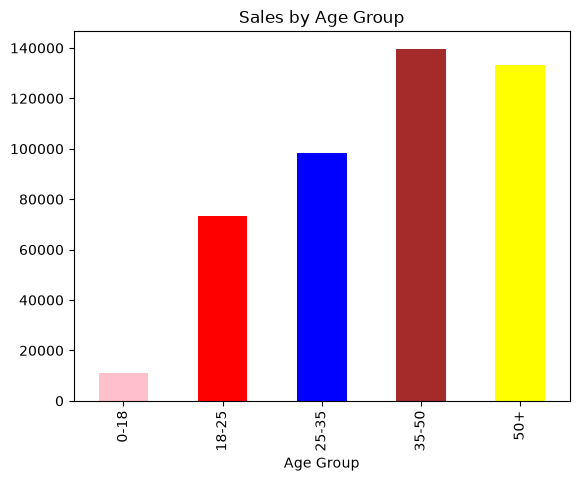

In [79]:
bins = [0, 18, 25, 35, 50, 100]
labels = ['0-18', '18-25', '25-35', '35-50', '50+']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_sales = df.groupby('Age Group')['Total Amount'].sum()
age_sales.plot(kind='bar', title='Sales by Age Group', color = ['Pink','Red', 'Blue', 'Brown','yellow'])
plt.show()

In [80]:
save_plot('Sales by Age Group')

In [82]:
High_Paycustomers = df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(5)
print(High_Paycustomers)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
Name: Total Amount, dtype: int64
